In [ ]:
!pip install

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  MonthlyCharges    594194 non-null  float64
 16  TotalCharges      59

In [14]:
df.drop(columns=['id'], inplace=True)

In [21]:
df.drop(columns=['PaperlessBilling', 'PaymentMethod'], inplace=True)

In [23]:
df.nunique()

gender                  2
SeniorCitizen           2
Partner                 2
Dependents              2
tenure                 72
PhoneService            2
MultipleLines           3
InternetService         3
OnlineSecurity          3
OnlineBackup            3
DeviceProtection        3
TechSupport             3
StreamingTV             3
StreamingMovies         3
Contract                3
MonthlyCharges       1921
TotalCharges        31910
Churn                   2
dtype: int64

In [28]:
for col in df.select_dtypes(include=['object']).columns:
    unique_values = df[col].dropna().unique()
    print(f"{col} : {unique_values}")

gender : ['Male' 'Female']
Partner : ['Yes' 'No']
Dependents : ['Yes' 'No']
PhoneService : ['Yes' 'No']
MultipleLines : ['No' 'Yes' 'No phone service']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['Yes' 'No' 'No internet service']
OnlineBackup : ['No' 'Yes' 'No internet service']
DeviceProtection : ['Yes' 'No' 'No internet service']
TechSupport : ['Yes' 'No' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['One year' 'Two year' 'Month-to-month']
Churn : ['No' 'Yes']


In [29]:
# Standardize categorical values - combine 'No internet service' and 'No phone service' to 'No'
# Replace 'No phone service' with 'No'
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Replace 'No internet service' with 'No' for these columns
internet_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                         'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_service_cols:
    df[col] = df[col].replace('No internet service', 'No')

print("Cleaned categorical values:")
for col in df.select_dtypes(include=['object']).columns:
    unique_values = df[col].dropna().unique()
    print(f"{col} : {unique_values}")

Cleaned categorical values:
gender : ['Male' 'Female']
Partner : ['Yes' 'No']
Dependents : ['Yes' 'No']
PhoneService : ['Yes' 'No']
MultipleLines : ['No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['Yes' 'No']
OnlineBackup : ['No' 'Yes']
DeviceProtection : ['Yes' 'No']
TechSupport : ['Yes' 'No']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']
Contract : ['One year' 'Two year' 'Month-to-month']
Churn : ['No' 'Yes']


In [42]:
# Apply One-Hot Encoder with smart handling of binary vs multi-category features
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical and numeric columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}\n")

# Separate binary and multi-category columns
binary_cols = []
multi_cols = []
for col in categorical_cols:
    n_unique = df[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"Binary columns: {binary_cols}")
print(f"Multi-category columns: {multi_cols}\n")

# Encode binary columns as 0/1
df_binary_encoded = pd.DataFrame()
for col in binary_cols:
    # Get unique values and encode first as 0, second as 1
    label_encoder = LabelEncoder()
    df_binary_encoded[f"{col}_1"] = label_encoder.fit_transform(df[col])

# Encode multi-category columns with all categories (drop=None)
encoder_multi = OneHotEncoder(drop=None, sparse_output=False)
df_multi_encoded = encoder_multi.fit_transform(df[multi_cols])

# Get clean feature names for multi-category columns
feature_names_multi = []
for i, col in enumerate(multi_cols):
    categories = encoder_multi.categories_[i]
    feature_names_multi.extend([f"{col}_{str(cat)}" for cat in categories])

# Get numeric data
numeric_data = df[numeric_cols].reset_index(drop=True).values

# Combine all data
df_combined = np.hstack([
    df_binary_encoded.values if len(binary_cols) > 0 else np.empty((len(df), 0)),
    df_multi_encoded,
    numeric_data
])

# Create feature names list
all_feature_names = list(df_binary_encoded.columns) + feature_names_multi + numeric_cols

# Create dataframe
df_encoded = pd.DataFrame(df_combined, columns=all_feature_names)

print("Encoded Data Shape:", df_encoded.shape)
print("\nAll column names:")
print(df_encoded.columns.tolist())

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'Churn']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Churn']
Multi-category columns: ['InternetService', 'Contract']

Encoded Data Shape: (594194, 22)

All column names:
['gender_1', 'Partner_1', 'Dependents_1', 'PhoneService_1', 'MultipleLines_1', 'OnlineSecurity_1', 'OnlineBackup_1', 'DeviceProtection_1', 'TechSupport_1', 'StreamingTV_1', 'StreamingMovies_1', 'Churn_1', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'SeniorCitizen', 'tenure', 'Mon

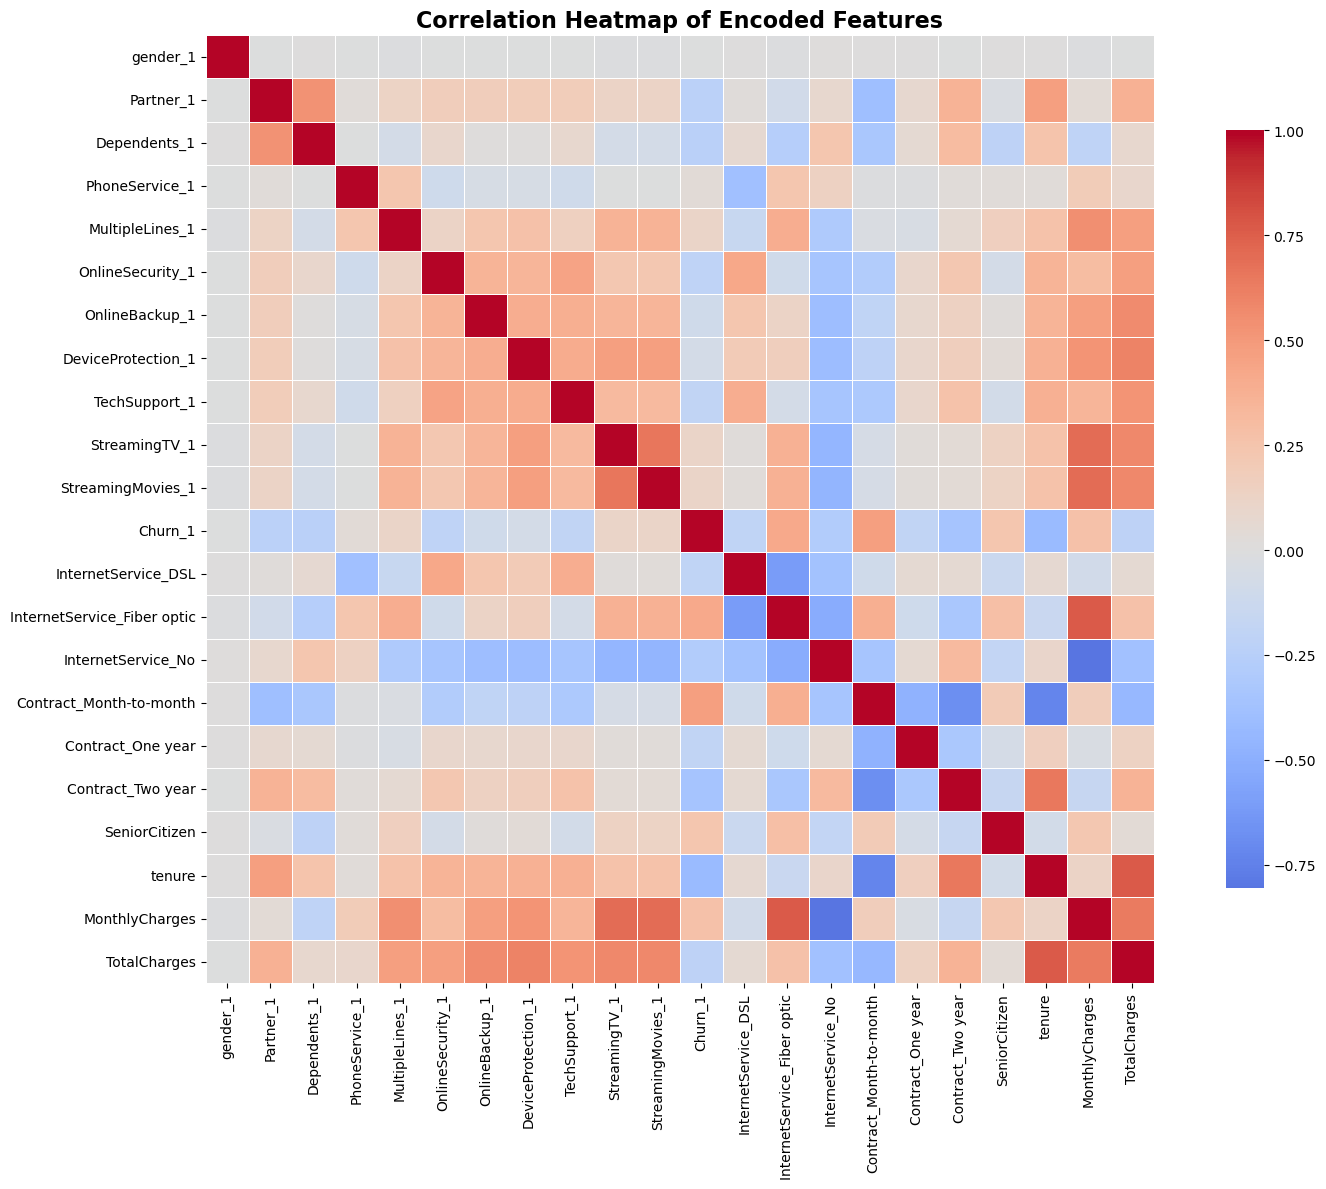

In [43]:
# Generate correlation heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Encoded Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Harshal\AppData\Local\Temp\ipykernel_15840\1211181142.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr_top.values, y=churn_corr_top.index, palette='coolwarm')


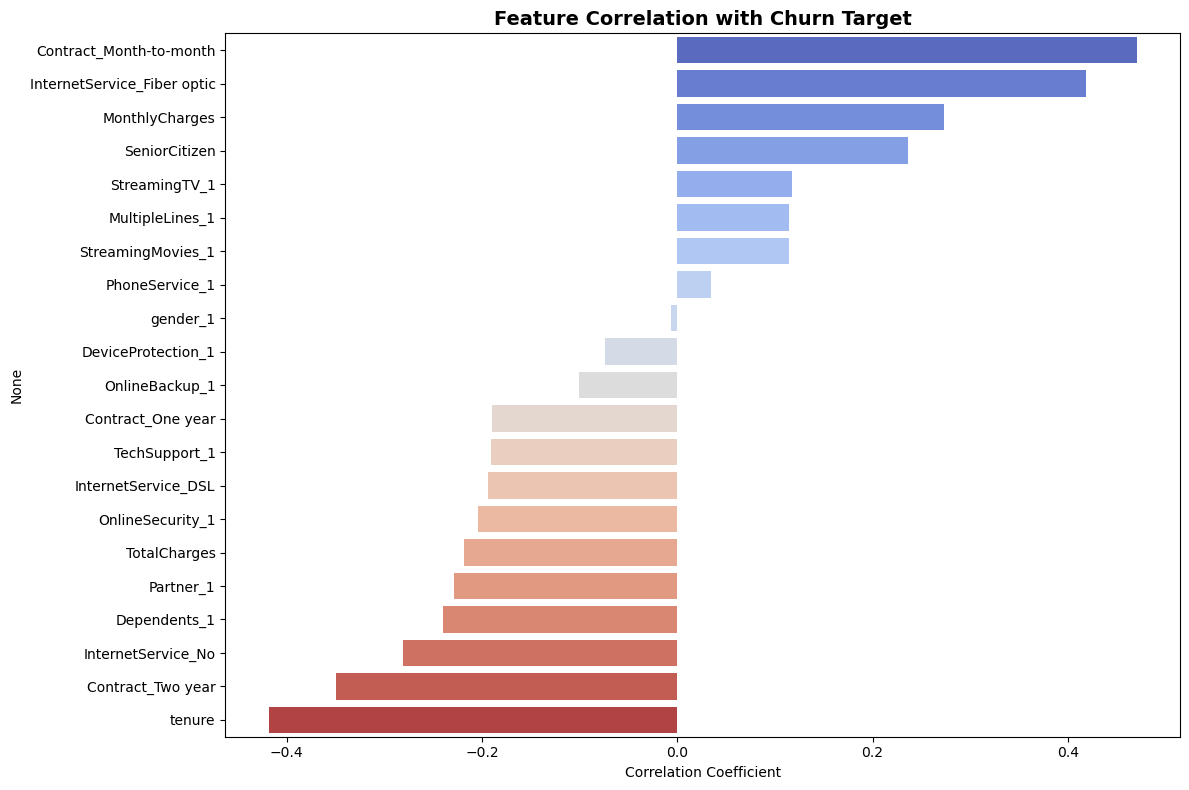


Top 10 features correlated with Churn:
Contract_Month-to-month        0.470500
InternetService_Fiber optic    0.418819
MonthlyCharges                 0.272997
SeniorCitizen                  0.236362
StreamingTV_1                  0.117280
MultipleLines_1                0.114951
StreamingMovies_1              0.114589
PhoneService_1                 0.034843
gender_1                      -0.006808
DeviceProtection_1            -0.074228
Name: Churn_1, dtype: float64


In [44]:
# Generate heatmap of top correlations with target variable (Churn)
# Find churn columns dynamically
churn_cols = [col for col in df_encoded.columns if 'Churn' in col]

if len(churn_cols) > 0:
    churn_col = churn_cols[0]  # Take first churn column
    
    # Get correlations with Churn target
    churn_corr = df_encoded.corr()[churn_col].sort_values(ascending=False)
    
    # Exclude the churn column itself
    churn_corr = churn_corr[churn_corr.index != churn_col]
    
    plt.figure(figsize=(12, 8))
    churn_corr_top = pd.concat([churn_corr.head(15), churn_corr.tail(14)])
    sns.barplot(x=churn_corr_top.values, y=churn_corr_top.index, palette='coolwarm')
    plt.title('Feature Correlation with Churn Target', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 features correlated with Churn:")
    print(churn_corr.head(10))

In [45]:
df_encoded.drop(columns=['gender_1', 'PhoneService_1'], inplace=True)

In [55]:
# Prepare data for XGBoost training
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Find churn columns dynamically
churn_cols = [col for col in df_encoded.columns if 'Churn' in col]
churn_col = churn_cols[0]  # Take first churn column

# Separate features and target
X = df_encoded.drop(columns=[churn_col])
y = df_encoded[churn_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Split data for training
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Features shape: (594194, 19)
Target shape: (594194,)
Target distribution:
Churn_1
0.0    460377
1.0    133817
Name: count, dtype: int64

Training set size: (475355, 19)
Validation set size: (118839, 19)


In [56]:
# Train multiple classification models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=False)
}

# Train and evaluate each model
results = {}
predictions = {}

print("Training multiple models...\n")
print("=" * 80)

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Train model
    if model_name == 'XGBoost':
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else:
        model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results[model_name] = {'Accuracy': accuracy, 'ROC-AUC': roc_auc}
    predictions[model_name] = y_pred_proba
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

# Create comparison dataframe
results_df = pd.DataFrame(results).T
print("\n" + "=" * 80)
print("\nModel Performance Comparison:")
print(results_df)

# Find best model
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\nBest model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f})")

Training multiple models...


Training Logistic Regression...
  Accuracy: 0.8508
  ROC-AUC: 0.9044

Training Random Forest...
  Accuracy: 0.8539
  ROC-AUC: 0.9091

Training XGBoost...
  Accuracy: 0.8568
  ROC-AUC: 0.9118

Training LightGBM...
  Accuracy: 0.8565
  ROC-AUC: 0.9117

Training CatBoost...
  Accuracy: 0.8553
  ROC-AUC: 0.9103


Model Performance Comparison:
                     Accuracy   ROC-AUC
Logistic Regression  0.850840  0.904434
Random Forest        0.853920  0.909127
XGBoost              0.856840  0.911785
LightGBM             0.856503  0.911716
CatBoost             0.855334  0.910268

Best model: XGBoost (ROC-AUC: 0.9118)


In [57]:
# Load and preprocess test data
df_test = pd.read_csv('test.csv')

print("Test data shape:", df_test.shape)
print("\nTest data info:")
print(df_test.info())

# Store test IDs
test_ids = df_test['id'].copy()

# Drop unnecessary columns (same as training data)
df_test.drop(columns=['id'], inplace=True)
df_test.drop(columns=['PaperlessBilling', 'PaymentMethod'], inplace=True)

# Apply same categorical standardization
df_test['MultipleLines'] = df_test['MultipleLines'].replace('No phone service', 'No')
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_test[col] = df_test[col].replace('No internet service', 'No')

# Get categorical and numeric columns
test_categorical_cols = df_test.select_dtypes(include=['object']).columns.tolist()
test_numeric_cols = df_test.select_dtypes(exclude=['object']).columns.tolist()

# Encode binary columns
df_test_binary_encoded = pd.DataFrame()
for col in binary_cols:
    if col in test_categorical_cols:
        label_encoder = LabelEncoder()
        df_test_binary_encoded[f"{col}_1"] = label_encoder.fit_transform(df_test[col])

# Encode multi-category columns using same encoder
df_test_multi_encoded = encoder_multi.transform(df_test[multi_cols])

# Get clean feature names for multi-category columns (same as training)
test_feature_names_multi = []
for i, col in enumerate(multi_cols):
    categories = encoder_multi.categories_[i]
    test_feature_names_multi.extend([f"{col}_{str(cat)}" for cat in categories])

# Get numeric data
test_numeric_data = df_test[test_numeric_cols].reset_index(drop=True).values

# Combine all data
df_test_combined = np.hstack([
    df_test_binary_encoded.values if len(binary_cols) > 0 else np.empty((len(df_test), 0)),
    df_test_multi_encoded,
    test_numeric_data
])

# Create feature names for test data (same order as X training features)
test_feature_names = list(df_test_binary_encoded.columns) + test_feature_names_multi + test_numeric_cols

df_test_encoded = pd.DataFrame(df_test_combined, columns=test_feature_names)

# Ensure columns match training features exactly
df_test_encoded = df_test_encoded[X.columns]

print(f"\nTest encoded shape: {df_test_encoded.shape}")
print(f"Training features shape: {X.shape}")
print(f"Columns match: {list(X.columns) == list(df_test_encoded.columns)}")

Test data shape: (254655, 20)

Test data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254

In [58]:
# Make ensemble predictions on test data
print("Making ensemble predictions on test data...")

# Get predictions from each model
ensemble_predictions = pd.DataFrame()
for model_name, model in models.items():
    y_test_pred_proba = model.predict_proba(df_test_encoded)[:, 1]
    ensemble_predictions[model_name] = y_test_pred_proba

print(f"Predictions shape: {ensemble_predictions.shape}")
print(f"\nPredictions from each model (first 5 rows):")
print(ensemble_predictions.head())

# Create ensemble by averaging predictions
ensemble_avg = ensemble_predictions.mean(axis=1)
print(f"\nEnsemble average (first 10 predictions):")
print(ensemble_avg.head(10))

# Also use best individual model
best_model = models[best_model_name]
best_model_predictions = best_model.predict_proba(df_test_encoded)[:, 1]

print(f"\nBest model ({best_model_name}) predictions (first 10):")
print(best_model_predictions[:10])

Making ensemble predictions on test data...
Predictions shape: (254655, 5)

Predictions from each model (first 5 rows):
   Logistic Regression  Random Forest   XGBoost  LightGBM  CatBoost
0             0.024478       0.027378  0.026918  0.024780  0.034964
1             0.000164       0.001157  0.001147  0.001006  0.002542
2             0.132990       0.137469  0.099927  0.102412  0.113787
3             0.003577       0.004201  0.005155  0.005267  0.005600
4             0.570541       0.623039  0.558252  0.567730  0.579421

Ensemble average (first 10 predictions):
0    0.027704
1    0.001203
2    0.117317
3    0.004760
4    0.579796
5    0.252401
6    0.773550
7    0.002372
8    0.055684
9    0.286649
dtype: float64

Best model (XGBoost) predictions (first 10):
[0.02691813 0.0011473  0.09992672 0.00515535 0.55825156 0.22927813
 0.8717048  0.00272446 0.05466229 0.27683634]


In [53]:
# Create and export submissions
# Option 1: Ensemble submission (average of all models)
submission_ensemble = pd.DataFrame({
    'id': test_ids.values,
    'Churn': ensemble_avg
})

print("Ensemble Submission (first 10 rows):")
print(submission_ensemble.head(10))

submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print("\nEnsemble submission saved to submission_ensemble.csv!")

# Option 2: Best model submission
submission_best = pd.DataFrame({
    'id': test_ids.values,
    'Churn': best_model_predictions
})

print(f"\n{best_model_name} Submission (first 10 rows):")
print(submission_best.head(10))

submission_best.to_csv(f'submission_{best_model_name.replace(" ", "_")}.csv', index=False)
print(f"\nBest model submission saved to submission_{best_model_name.replace(' ', '_')}.csv!")

# Summary
print("\n" + "=" * 80)
print("SUBMISSION SUMMARY")
print("=" * 80)
print(f"\n✓ Ensemble submission: submission_ensemble.csv")
print(f"✓ Best model submission: submission_{best_model_name.replace(' ', '_')}.csv")
print(f"\nBest Model: {best_model_name}")
print(f"Validation ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")

Ensemble Submission (first 10 rows):
       id     Churn
0  594194  0.027704
1  594195  0.001203
2  594196  0.117317
3  594197  0.004760
4  594198  0.579796
5  594199  0.252401
6  594200  0.773550
7  594201  0.002372
8  594202  0.055684
9  594203  0.286649

Ensemble submission saved to submission_ensemble.csv!

XGBoost Submission (first 10 rows):
       id     Churn
0  594194  0.026918
1  594195  0.001147
2  594196  0.099927
3  594197  0.005155
4  594198  0.558252
5  594199  0.229278
6  594200  0.871705
7  594201  0.002724
8  594202  0.054662
9  594203  0.276836

Best model submission saved to submission_XGBoost.csv!

SUBMISSION SUMMARY

✓ Ensemble submission: submission_ensemble.csv
✓ Best model submission: submission_XGBoost.csv

Best Model: XGBoost
Validation ROC-AUC: 0.9118


In [ ]:
# Train SVM separately
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

print("Training SVM Classifier...\n")

# Scale features for SVM (SVM is sensitive to feature scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
print("(Note: SVM training may take longer on large datasets...)")
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_svm_pred = svm_model.predict(X_val_scaled)
y_svm_pred_proba = svm_model.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
svm_accuracy = accuracy_score(y_val, y_svm_pred)
svm_roc_auc = roc_auc_score(y_val, y_svm_pred_proba)

print(f"\nSVM Training Results:")
print(f"  Accuracy: {svm_accuracy:.4f}")
print(f"  ROC-AUC: {svm_roc_auc:.4f}")

Training SVM Classifier...

(Note: SVM training may take longer on large datasets...)


In [ ]:
# Make SVM predictions on test data
print("Making SVM predictions on test data...\n")

# Scale test data using the same scaler
df_test_encoded_scaled = scaler.transform(df_test_encoded)

# Get probability predictions from SVM
svm_test_predictions = svm_model.predict_proba(df_test_encoded_scaled)[:, 1]

print(f"SVM predictions shape: {svm_test_predictions.shape}")
print(f"Sample SVM predictions (first 10):")
print(svm_test_predictions[:10])

In [ ]:
# Export SVM submission
print("Creating SVM submission...\n")

submission_svm = pd.DataFrame({
    'id': test_ids.values,
    'Churn': svm_test_predictions
})

print("SVM Submission (first 10 rows):")
print(submission_svm.head(10))

submission_svm.to_csv('submission_SVM.csv', index=False)
print("\nSVM submission saved to submission_SVM.csv!")

print("\n" + "=" * 80)
print("SVM MODEL SUMMARY")
print("=" * 80)
print(f"Validation Accuracy: {svm_accuracy:.4f}")
print(f"Validation ROC-AUC: {svm_roc_auc:.4f}")
print(f"Submission file: submission_SVM.csv")